# **언어 모델 활용_모델 Fine_Tuning**

## 1.환경준비

### (1) 라이브러리 설치 및 로딩

In [ ]:
!pip install datasets peft accelerate -q

* 설치 후 세션 다시 시작

In [3]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

import torch

from transformers import AutoTokenizer, AutoModelForSequenceClassification, Trainer, TrainingArguments, EarlyStoppingCallback
from datasets import load_dataset, Dataset

from sklearn.model_selection import train_test_split
from sklearn.metrics import *

from warnings import filterwarnings
FutureWarning
filterwarnings('ignore')

* 함수 생성

In [2]:
# 검증셋 평가 함수
def evaluate(val_ds, model, device, tokenizer):
    # 입력 데이터셋 토크나이징 (attention_mask 포함)
    inputs = tokenizer(list(val_ds['text']), return_tensors="pt", padding=True,
                       truncation=True, max_length=128
    )
    inputs = {key: value.to(device) for key, value in inputs.items()}  # 입력 텐서를 동일한 디바이스로 이동

    # 모델을 지정된 디바이스로 이동
    model = model.to(device)

    with torch.no_grad():  # 평가 과정에서 기울기 계산 비활성화
        outputs = model(**inputs)  # attention_mask를 포함해 입력

    # 예측 및 확률 계산
    probabilities = outputs.logits.softmax(dim=1)

    # probabilities가 GPU에 있을 경우에만 CPU로 이동
    if probabilities.is_cuda:
        probabilities = probabilities.cpu().detach().numpy()
    else:
        probabilities = probabilities.detach().numpy()

    pred = np.argmax(probabilities, axis=1)

    # GPU 메모리에서 필요 없는 텐서 제거 및 캐시 정리
    del inputs
    torch.cuda.empty_cache()

    return pred, probabilities

In [3]:
def predict(text, model, tokenizer):
    # 모델을 CPU로 이동
    model = model.to("cpu")

    # 입력 문장 토크나이징 → CPU 텐서로 생성
    inputs = tokenizer(text, return_tensors="pt", truncation=True, padding=True)

    # 모델 예측 (no_grad로 메모리 절약)
    with torch.no_grad():
        outputs = model(**inputs)

    # 확률 계산
    logits = outputs.logits
    probabilities = torch.softmax(logits, dim=1)

    # 예측 클래스
    pred = torch.argmax(probabilities, dim=-1).item()

    return pred, probabilities


### (2) 구글드라이브 연결
* 자신의 구글 드라이브에 langchain 폴더 만들기
* 다운로드 받은 파일을 langchain 폴더에 업로드 합니다.

In [4]:
path = './(5주차) RAG기반 Agent 개발/'

### (3) 데이터 로딩

In [5]:
data = pd.read_csv('https://raw.githubusercontent.com/DA4BAM/dataset/refs/heads/master/emotions.csv')
data.head()

,text,label
0,i didnt feel humiliated,0
1,i can go from feeling so hopeless to so damned...,0
2,im grabbing a minute to post i feel greedy wrong,3
3,i am ever feeling nostalgic about the fireplac...,2
4,i am feeling grouchy,3


* y 분포 확인하기

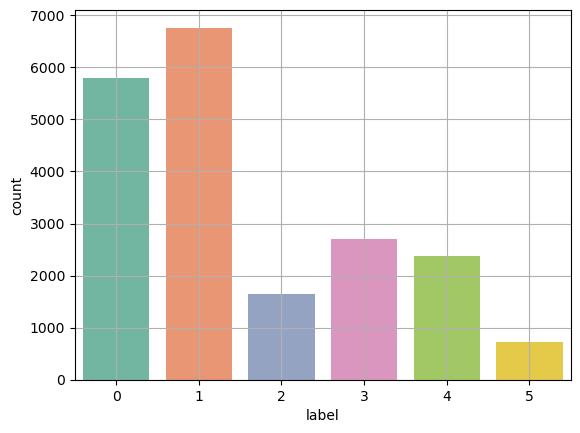

In [6]:
sns.countplot(x='label', data = data, palette='Set2')
plt.grid()
plt.show()

* label : anger(0), fear(1), joy(2), love(3), sadness(4), and surprise(5)

In [7]:
label_list = ['anger', 'fear', 'joy', 'love', 'sadness', 'surprise']

### (4) GPU 설정
* 파이토치를 위한 설정

In [8]:
# GPU 설정
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
device

device(type='cuda')

## 2.데이터 준비

### (1) Dataset 만들기 : train, val

In [9]:
train, val = train_test_split(data, test_size=0.2, random_state=42)

In [10]:
from datasets import Dataset

# df로 부터 텐서 데이터셋 만들기
train_ts = Dataset.from_pandas(train)
val_ts = Dataset.from_pandas(val)

In [11]:
train_ts[:3]

{'text': ['i was getting motivated about losing weight and getting healthy and wearing that outfit and feeling fantastic',
  'i feel very delighted for my stay here in manila is nearing its end and feel so down for the same reason',
  'i didnt respond because i feel that some days i cant just put on a fake smile and pretend like life is great and not let the negativity creep in'],
 'label': [1, 1, 0],
 '__index_level_0__': [5894, 3728, 8958]}

### (2) 토크나이징

In [12]:
# 모델과 토크나이저 불러오기
model_name = "distilbert-base-uncased"
tokenizer = AutoTokenizer.from_pretrained(model_name)

In [13]:
# 토큰화 함수 생성 및 작업
def preprocess_function(data):
    return tokenizer(data['text'], truncation=True, padding=True)

train_ts = train_ts.map(preprocess_function, batched=True)
val_ts = val_ts.map(preprocess_function, batched=True)

Map: 100%|██████████| 4000/4000 [00:00<00:00, 28641.94 examples/s]


In [14]:
train_ts[0]

{'text': 'i was getting motivated about losing weight and getting healthy and wearing that outfit and feeling fantastic',
 'label': 1,
 '__index_level_0__': 5894,
 'input_ids': [101,
  1045,
  2001,
  2893,
  12774,
  2055,
  3974,
  3635,
  1998,
  2893,
  7965,
  1998,
  4147,
  2008,
  11018,
  1998,
  3110,
  10392,
  102,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0],
 'attention_mask': [1,
  1,
  1,
  1,
  1,
  1,
  1,
  1,
  1,
  1,
  1,
  1,
  1,
  1,
  1,
  1,
  1,
  1,
  1,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0]}

## 3.Fine-Tuning

* Fine-tuning 이란
    - 사전 훈련된(pre-trained) 모델을, 특정 작업이나 데이터셋에 맞게 미세 조정(fine-tuning)하는 과정

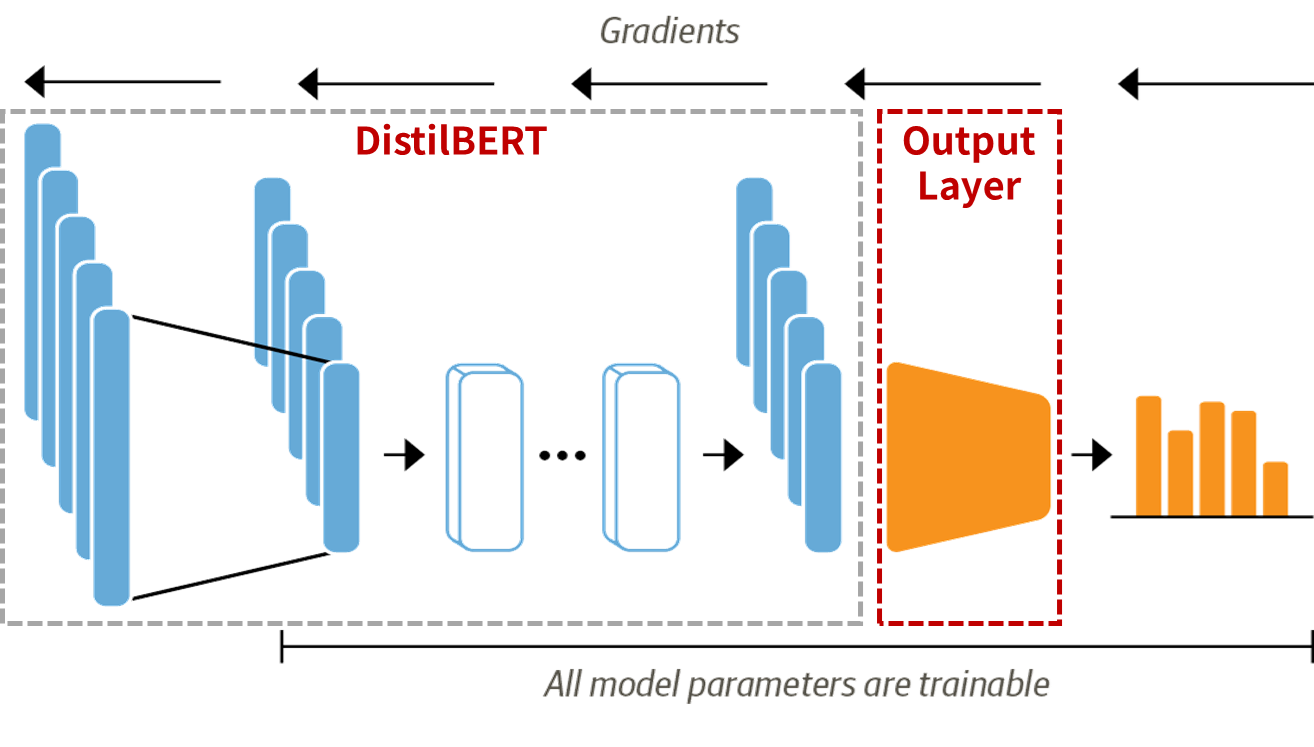

### (1) 사전학습 모델 준비

In [15]:
# 모델 설정 (다중 분류를 위해 num_labels 지정)
n = 6
model = AutoModelForSequenceClassification.from_pretrained(model_name,
                                                           num_labels = n).to(device)

Some weights of DistilBertForSequenceClassification were not initialized from the model checkpoint at distilbert-base-uncased and are newly initialized: ['classifier.bias', 'classifier.weight', 'pre_classifier.bias', 'pre_classifier.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


In [16]:
from transformers import logging
logging.set_verbosity_info()

### (2) 학습

* TrainingArguments 설정
    * Hugging Face의 transformers 라이브러리에서 모델 학습에 필요한 다양한 설정을 지정하는데 사용

In [ ]:
training_args = TrainingArguments(
    output_dir = './results',
    eval_strategy = "epoch",
    save_strategy = "epoch",
    learning_rate = 2e-5,               # 작은 학습률
    per_device_train_batch_size = 32,   # 학습 배치 사이즈
    per_device_eval_batch_size = 32,
    num_train_epochs = 5,               # 에폭 수
    weight_decay = 0.02,                # weight decay
    load_best_model_at_end = True,      # earlystopping 사용하기 위해 필요
    logging_dir ='./logs',
    logging_steps = 10,
    report_to="tensorboard"
)

PyTorch: setting up devices


* Trainer
    * Hugging Face의 transformers 라이브러리에서 제공하는 고수준 API로, 모델 학습과 평가를 쉽게 할 수 있도록 도와주는 클래스

In [18]:
# Trainer 설정
trainer = Trainer(
    model=model,                         # 학습할 모델
    args=training_args,                  # TrainingArguments
    train_dataset = train_ts,
    eval_dataset = val_ts,
    tokenizer = tokenizer,
    callbacks = [EarlyStoppingCallback(early_stopping_patience=3)], # 조기 종료
)

In [ ]:
# 모델 학습(6~10분 소요)
trainer.train()

In [ ]:
# 모델 평가
eval_results = trainer.evaluate()
print(f"Evaluation results: {eval_results}")

The following columns in the Evaluation set don't have a corresponding argument in `DistilBertForSequenceClassification.forward` and have been ignored: __index_level_0__, text. If __index_level_0__, text are not expected by `DistilBertForSequenceClassification.forward`,  you can safely ignore this message.

***** Running Evaluation *****
  Num examples = 4000
  Batch size = 32


Evaluation results: {'eval_loss': 0.13849203288555145, 'eval_runtime': 2.9927, 'eval_samples_per_second': 1336.586, 'eval_steps_per_second': 41.768, 'epoch': 5.0}


### (3) 모델 사용

In [20]:
text = "I'm absolutely thrilled with the way everything turned out!"
predicted_class, probabilities = predict(text, model, tokenizer)

print(f"예측된 클래스: {predicted_class}")
print(f"예측된 클래스 이름: {label_list[predicted_class]}")
print(f"클래스별 확률: {probabilities}")

예측된 클래스: 1
예측된 클래스 이름: fear
클래스별 확률: tensor([[0.2119, 0.4024, 0.1020, 0.1075, 0.1070, 0.0692]])


### (4) 모델 검증평가

In [ ]:
predictions_output = trainer.predict(val_ts)

In [27]:
logits = predictions_output.predictions
pred = np.argmax(logits, axis=1)

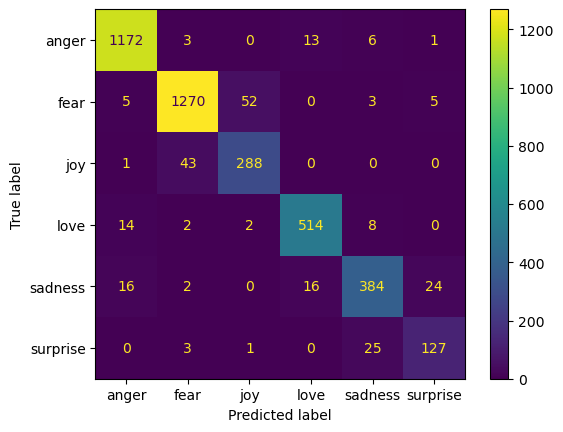

              precision    recall  f1-score   support

       anger       0.97      0.98      0.98      1195
        fear       0.96      0.95      0.96      1335
         joy       0.84      0.87      0.85       332
        love       0.95      0.95      0.95       540
     sadness       0.90      0.87      0.88       442
    surprise       0.81      0.81      0.81       156

    accuracy                           0.94      4000
   macro avg       0.90      0.91      0.90      4000
weighted avg       0.94      0.94      0.94      4000



In [28]:
from sklearn.metrics import ConfusionMatrixDisplay
disp = ConfusionMatrixDisplay(confusion_matrix(val_ts['label'], pred), display_labels = label_list)
disp.plot()
plt.show()

print(classification_report(val_ts['label'], pred, target_names = label_list))

## 4.[추가]허깅페이스에 모델 등록

### (1) 구글 드라이브에 모델 저장하기

In [ ]:
fine_tuned_path = path + 'fine_tuned_model'
model.save_pretrained(fine_tuned_path)
tokenizer.save_pretrained(fine_tuned_path)

### (2) 허깅페이스에 모델 등록
웹사이트를 통해 파일을 Hub로 업로드 : 모델 저장소를 만들고, 파일 업로드

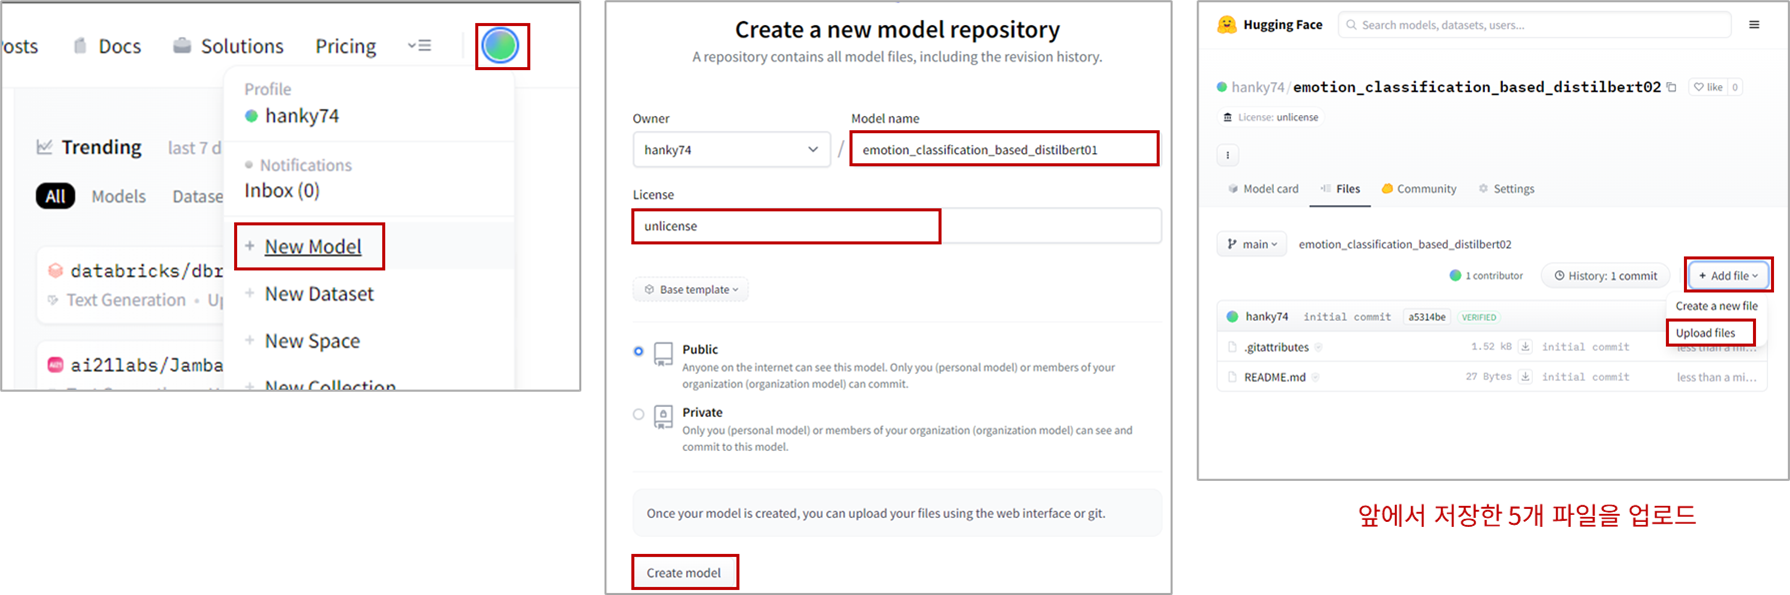

### (3) 허깅페이스에 모델 사용

* 모델 다운로드
    * pipeline 함수를 이용해서 모델을 다운로드
* 모델 사용
    * 입력 : 문장
    * 출력 : 감정 분류 결과 ['sadness', 'joy', 'love', 'anger', 'fear', 'surprise’]


In [ ]:
from transformers import pipeline
emotion_classifier = pipeline(task = 'text-classification', model = 'hanky74/emotion_distilbert02')

In [ ]:
emotion_classifier('I am really happy to see you again!')

## 5.[추가]LoRA(Low-Rank Adaptation)

**LoRA (Low-Rank Adaptation)**
- 기존에 학습된 내용은 유지하면서, 새로운 데이터에만 필요한 변화만 살짝 추가하는 방식
- 파인튜닝 데이터에서 기존 가중치와 다른 "차이"만 반영


*(앞서 진행했던 2. 데이터준비까지 실행한 후 다음 실행)*

### (1) 라이브러리 로딩

In [31]:
from peft import get_peft_model, LoraConfig, TaskType

### (2) 사전학습 모델 준비
* 위에서 적용한 내용

In [32]:
# 기본 설정
model_name = "distilbert-base-uncased"
num_labels = 6
tokenizer = AutoTokenizer.from_pretrained(model_name)

# 사전 학습된 모델 로드 (전체 파라미터는 그대로)
base_model = AutoModelForSequenceClassification.from_pretrained(model_name, num_labels=num_labels)

loading configuration file config.json from cache at C:\Users\USER\.cache\huggingface\hub\models--distilbert-base-uncased\snapshots\12040accade4e8a0f71eabdb258fecc2e7e948be\config.json
Model config DistilBertConfig {
  "activation": "gelu",
  "architectures": [
    "DistilBertForMaskedLM"
  ],
  "attention_dropout": 0.1,
  "dim": 768,
  "dropout": 0.1,
  "hidden_dim": 3072,
  "initializer_range": 0.02,
  "max_position_embeddings": 512,
  "model_type": "distilbert",
  "n_heads": 12,
  "n_layers": 6,
  "pad_token_id": 0,
  "qa_dropout": 0.1,
  "seq_classif_dropout": 0.2,
  "sinusoidal_pos_embds": false,
  "tie_weights_": true,
  "transformers_version": "4.57.1",
  "vocab_size": 30522
}

loading file vocab.txt from cache at C:\Users\USER\.cache\huggingface\hub\models--distilbert-base-uncased\snapshots\12040accade4e8a0f71eabdb258fecc2e7e948be\vocab.txt
loading file tokenizer.json from cache at C:\Users\USER\.cache\huggingface\hub\models--distilbert-base-uncased\snapshots\12040accade4e8a0f7

### (3) LoRA 구성

In [33]:
# LoRA 구성 정의
lora_config = LoraConfig(
    task_type=TaskType.SEQ_CLS,  # 시퀀스 분류
    r=8,                         # 랭크 값 (작을수록 파라미터 적음)
    lora_alpha=32,               # 너무 작으면 학습 효과 약하고, 너무 크면 발산 위험
    lora_dropout=0.1,
    target_modules=["q_lin", "v_lin"],  # DistilBERT에서 사용되는 attention 레이어 이름
    bias="none"                 # bias는 학습하지 않음
)

# LoRA 적용 (일부 레이어만 학습)
model = get_peft_model(base_model, lora_config)

### (4) 학습
* 위 코드 그대로

In [ ]:
# TrainingArguments (기존 Trainer 그대로 사용 가능)
training_args = TrainingArguments(
    output_dir = './results',
    eval_strategy = "epoch",
    save_strategy = "epoch",
    learning_rate = 2e-4,               # LoRA는 조금 큰 학습률
    per_device_train_batch_size = 32,   # 학습 배치 사이즈
    per_device_eval_batch_size = 32,
    num_train_epochs = 5,               # 에폭 수
    weight_decay = 0.02,                # weight decay
    load_best_model_at_end = True,      # earlystopping 사용하기 위해 필요
    logging_dir ='./logs',
    logging_steps = 10,
    report_to="tensorboard"
)

# Trainer 설정 (compute_metrics, callbacks 등 필요 시 추가)
trainer = Trainer(
    model=model,
    args=training_args,
    train_dataset=train_ts,
    eval_dataset=val_ts,
    tokenizer=tokenizer,
    callbacks=[EarlyStoppingCallback(early_stopping_patience=2)]
)

PyTorch: setting up devices


In [ ]:
# 학습 시작
trainer.train()

### (5) 모델 사용

In [43]:
text = "I'm absolutely thrilled with the way everything turned out!"
predicted_class, probabilities = predict(text, model, tokenizer)

print(f"예측된 클래스: {predicted_class}")
print(f"예측된 클래스 이름: {label_list[predicted_class]}")
print(f"클래스별 확률: {probabilities}")

예측된 클래스: 1
예측된 클래스 이름: fear
클래스별 확률: tensor([[0.1823, 0.1845, 0.1534, 0.1570, 0.1525, 0.1704]])


### (6) 모델 검증평가

In [ ]:
pred, prob = evaluate(val_ts, model, device, tokenizer)

In [ ]:
from sklearn.metrics import ConfusionMatrixDisplay
disp = ConfusionMatrixDisplay(confusion_matrix(val_ts['label'], pred), display_labels = label_list)
disp.plot()
plt.show()

print(classification_report(val_ts['label'], pred, target_names = label_list))